# TASK 1: Regression Analysis

In [13]:
##Importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [20]:
## Preparing of Tools for Modelling
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split 

In [21]:
##Importing Dataset
iris = pd.read_csv("1) iris.csv")
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [22]:
##Spliting dataset
iris.head(5)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [25]:
##Spliting Dataset into Training and Testing sets
x = iris.drop(["petal_length", "species"], axis = 1)
y = iris['petal_length']
np.random.seed(45)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [37]:
##Linear Regression Model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [55]:
## Get Coefficient
print("Intercept = ",model.intercept_)
print("Slope = ",model.coef_[0])

Intercept =  -0.11633890283839321
Slope =  0.6927575532503571


In [46]:
## Regression Report
from sklearn.metrics import r2_score, mean_squared_error

##calculating metrics
y_pred = model.predict(x_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
coef_summary = pd.DataFrame({'Feature': x.columns, 'Weight': model.coef_})
print("Mean Squared Error = ", mse)
print("R Squared = ", r2)
print(coef_summary)

Mean Squared Error =  0.11706791751748623
R Squared =  0.9647168518211557
        Feature    Weight
0  sepal_length  0.692758
1   sepal_width -0.638204
2   petal_width  1.485176


### Visualizing Regression Line


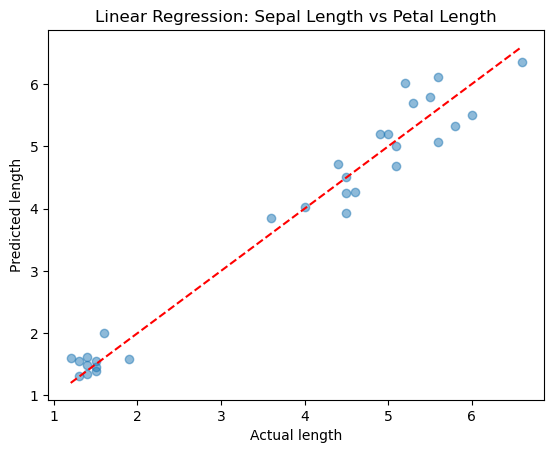

In [48]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual length')
plt.ylabel('Predicted length')
plt.title('Linear Regression: Sepal Length vs Petal Length')
plt.show()

In [52]:
x = iris[["sepal_length"]]
y = iris[["petal_length"]]

### Predicted Result

In [56]:
y_pred = model.predict(x_test)
pd.DataFrame({"Actual": y_test, "Predicted": y_pred}).head()

,Actual,Predicted
0,1.4,1.480045
43,1.6,2.004839
129,5.8,5.333184
3,1.5,1.388948
34,1.5,1.448257


# TASK 2 : TIME SERIES-ANALYSIS

### Data Cleaning and Preprocessing

In [1]:
## Importing DataSet
import pandas as pd
SPD = pd.read_csv("2) Stock Prices Data Set.csv")
SPD



,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391
...,...,...,...,...,...,...,...
497467,XYL,2017-12-29,68.5300,68.8000,67.9200,68.2000,1046677
497468,YUM,2017-12-29,82.6400,82.7100,81.5900,81.6100,1347613
497469,ZBH,2017-12-29,121.7500,121.9500,120.6200,120.6700,1023624
497470,ZION,2017-12-29,51.2800,51.5500,50.8100,50.8300,1261916


In [2]:
SPD.info()
SPD.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  object 
 1   date    497472 non-null  object 
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 26.6+ MB


,open,high,low,close,volume
count,497461.000000,497464.000000,497464.000000,497472.000000,4.974720e+05
mean,86.352275,87.132562,85.552467,86.369082,4.253611e+06
std,101.471228,102.312062,100.570957,101.472407,8.232139e+06
min,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,41.690000,42.090000,41.280000,41.703750,1.080166e+06
50%,64.970000,65.560000,64.353700,64.980000,2.084896e+06
75%,98.410000,99.230000,97.580000,98.420000,4.271928e+06
max,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08


In [3]:
SPD.duplicated().sum()


np.int64(0)

In [4]:
SPD.date = pd.to_datetime(SPD.date, errors='coerce')
SPD.date.head()

0   2014-01-02
1   2014-01-02
2   2014-01-02
3   2014-01-02
4   2014-01-02
Name: date, dtype: datetime64[ns]

In [5]:
SPD.symbol = SPD.symbol.astype('category')
SPD.symbol.dtype

CategoricalDtype(categories=['A', 'AAL', 'AAP', 'AAPL', 'ABBV', 'ABC', 'ABT', 'ACN',
                  'ADBE', 'ADI',
                  ...
                  'XL', 'XLNX', 'XOM', 'XRAY', 'XRX', 'XYL', 'YUM', 'ZBH',
                  'ZION', 'ZTS'],
, ordered=False, categories_dtype=object)

In [6]:
numeric_cols = ['open', 'high', 'low', 'close', 'volume']
SPD[numeric_cols] = SPD[numeric_cols].apply(pd.to_numeric)

In [7]:
# DataSet Info
SPD.info()
# Summary Statistics
SPD.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   symbol  497472 non-null  category      
 1   date    497472 non-null  datetime64[ns]
 2   open    497461 non-null  float64       
 3   high    497464 non-null  float64       
 4   low     497464 non-null  float64       
 5   close   497472 non-null  float64       
 6   volume  497472 non-null  int64         
dtypes: category(1), datetime64[ns](1), float64(4), int64(1)
memory usage: 23.7 MB


,date,open,high,low,close,volume
count,497472,497461.000000,497464.000000,497464.000000,497472.000000,4.974720e+05
mean,2016-01-06 17:16:00.439984896,86.352275,87.132562,85.552467,86.369082,4.253611e+06
min,2014-01-02 00:00:00,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,2015-01-08 00:00:00,41.690000,42.090000,41.280000,41.703750,1.080166e+06
50%,2016-01-11 00:00:00,64.970000,65.560000,64.353700,64.980000,2.084896e+06
75%,2017-01-06 00:00:00,98.410000,99.230000,97.580000,98.420000,4.271928e+06
max,2017-12-29 00:00:00,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08
std,NaN,101.471228,102.312062,100.570957,101.472407,8.232139e+06


In [8]:
# Sort by symbol, then by date
SPD.sort_values(by=['symbol', 'date'])
# Reset index(clean numbering)
SPD.reset_index(drop=True, inplace=True)

### Plotting Time-Series Data

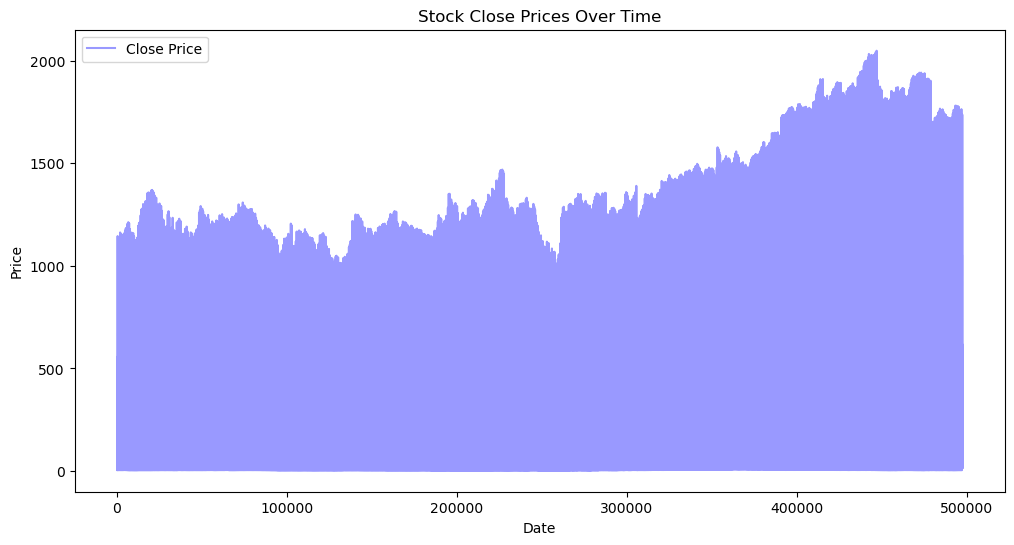

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(SPD.close, label='Close Price', color='blue', alpha=0.4)
plt.title("Stock Close Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend();

In [10]:
# Calculate moving averages
SPD['MA_7'] = SPD.close.rolling(window=7).mean()
SPD['MA_30'] = SPD.close.rolling(window=30).mean()

### Moving Average Smoothing Plot

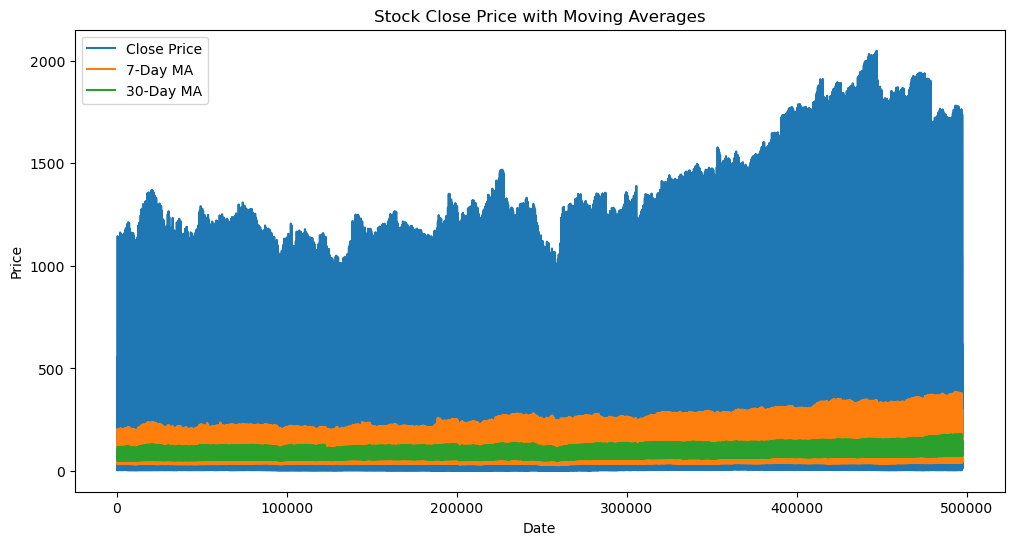

In [11]:
plt.figure(figsize=(12,6))
plt.plot(SPD.close, label='Close Price')
plt.plot(SPD['MA_7'], label='7-Day MA')
plt.plot(SPD['MA_30'], label = '30-Day MA')
plt.title("Stock Close Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend();

### Decompose Time Series

In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(SPD.close, model='additive',period=30)
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

In [14]:
# Decompose Timew Series Plot
plt.figure(figsize(12,10))
plt.subplot(411)
plt.plot(SPD.close, label = "Original")
plt.legend(loc="best")

plt.subplot(412)
plt.plot(trend, label="Trend")
plt.legend(loc="best")

plt.subplot(413)
plt.plot(seasonal, label="Seasonality")
plt.legend(loc="best")

plt.subplot(414)
plt.plot(residual, label="Residuals")
plt.legend(loc="best")

plt.tight_layout();

NameError: name 'figsize' is not defined